# Hello world (不要轻易运行，这个是实机！！！)

## This is a example that you can apply quantum circuit in QPU

Save your credentials locally with this code:

In [ ]:
# import json
# from pathlib import Path
# from qiskit_ibm_runtime import QiskitRuntimeService

# # 向上查找包含 apikey.json 的项目根目录
# root = Path.cwd()
# while root != root.parent and not (root / "apikey.json").exists():
#     root = root.parent

# with open(root / "apikey.json", "r", encoding="utf-8") as f:
#     data = json.load(f)

# API_KEY = data["apikey"]

# QiskitRuntimeService.save_account(
#     token=API_KEY,
#     instance="crn:v1:bluemix:public:quantum-computing:us-east:a/9b8bc3164f694c90b9e3e2b8be87175a:cf79926b-2b20-403b-9a23-d4aaf23cfbd7::",
#     overwrite=True,
# )

下面的service = QiskitRuntimeService() 是运行在真正的量子计算机的关键

In [1]:
# Every time you need the service

from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service

service = QiskitRuntimeService()


Now you have a Qiskit Runtime Service:

# Create and run a simple quantum program

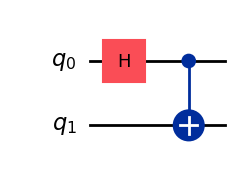

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")



初始状态:


<IPython.core.display.Latex object>

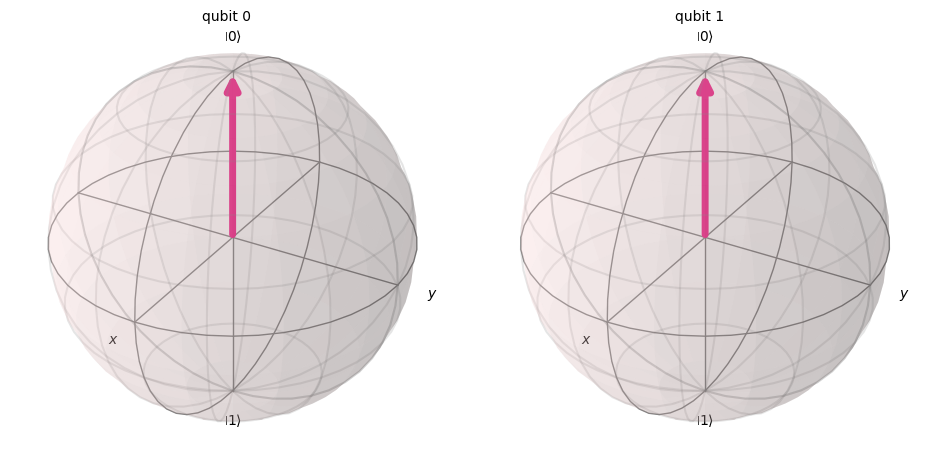


加入 H 门后的状态:


<IPython.core.display.Latex object>

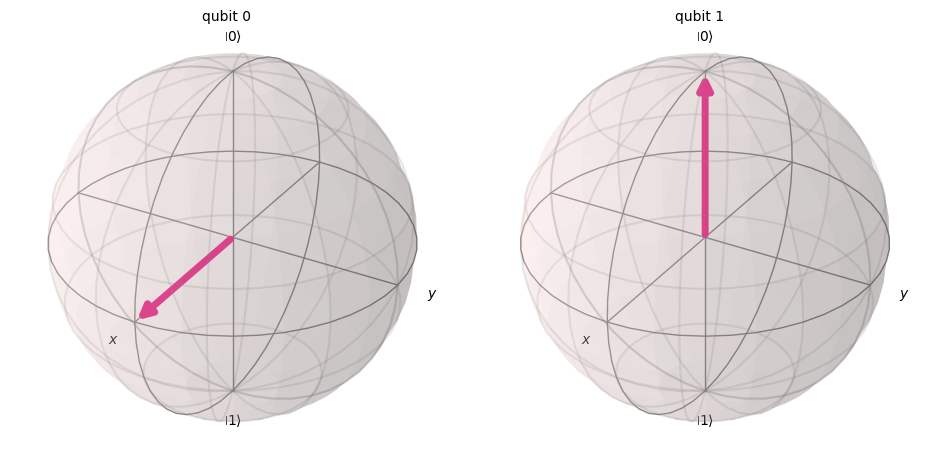


加入 CX 门后的状态 (贝尔态):


<IPython.core.display.Latex object>

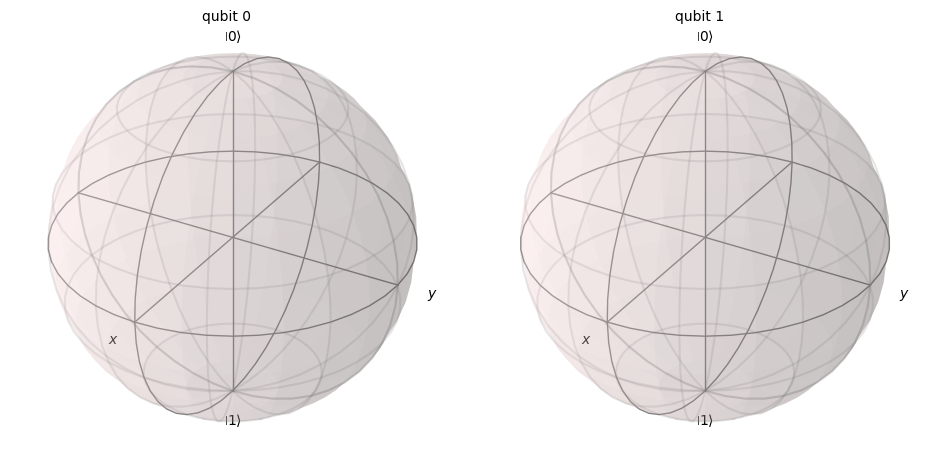

In [22]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# 1. 初始化
qc = QuantumCircuit(2)
print("初始状态:")
display(Statevector.from_instruction(qc).draw('latex'))
display(plot_bloch_multivector(Statevector.from_instruction(qc)))
# 2. 加入 Hadamard 门
qc.h(0)
print("\n加入 H 门后的状态:")
state1 = Statevector.from_instruction(qc)
display(state1.draw('latex'))
display(plot_bloch_multivector(state1))

# 3. 加入 CX 门
qc.cx(0, 1)
print("\n加入 CX 门后的状态 (贝尔态):")
state2 = Statevector.from_instruction(qc)
display(state2.draw('latex'))
display(plot_bloch_multivector(state2))


In [3]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

qc.measure_all()

# Result
sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'00': 466, '11': 558}


在编写量子电路时，你必须决定希望从执行结果中获得哪种类型的数据。Qiskit 提供了两种主要的数据返回路径，通过 Qiskit Primitives（基元）实现：

## 概率分布 (Probability Distribution)：

- 定义：获取你选择测量的特定量子比特集合出现不同状态（如 0 或 1）的概率。

- 适用基元：使用 Sampler。

- 输出形式：通常是一组比特串及其对应的计数或概率。

## 观测值的期望值 (Expectation Value of an Observable)：

- 定义：测量某个物理量（观测值）在当前量子态下的平均表现。

- 适用基元：使用 Estimator。

- 场景示例：在教程中，通过测量 ZZ 和 XX 等 Pauli 算符来评估量子比特之间的相关性，$ZZ$、$IX$、$XI$ 这些全是 $O$（Observables）的具体实例

一个简单的理解就是 我们可以通过 ZZ gate 实现两组 qubit的关系检验 
- 如果比特是 $|0\rangle$，它“吐出” $+1$
- 如果比特是 $|1\rangle$，它“吐出” $-1$
- 当你把两个 Z 门并排放在一起（即 $Z \otimes Z$）时，它变成了一个乘法评分器。它会把两个比特各自的 Z 读数相乘。


在这里 我们用6种不同Obeservable

IZ、IX、ZI、XI：测量单个量子比特的状态（独立性）。

ZZ、XX：测量两个量子比特之间的相关性（Correlation）。

In [10]:
# Set up six different observables.
 
observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

# 在真实量子硬件上，存在两个巨大的限制：

- 你想在 $q_0$ 和 $q_{10}$ 之间连 CNOT 门。但在真实的芯片上，$q_0$ 物理上可能只和 $q_1$ 相邻，它根本够不着 $q_{10}$

- 指令集限制（Basis Gates）：你用的 H 门、X 门，硬件不一定能直接读懂。每个量子芯片都有自己的“母语”（比如它只认识 $R_z, \sqrt{X}, CNOT$）。


这个就是量子计算的转译后的电路 (ISA Circuit)：就像是 汇编语言或机器码。它是为了适配特定的硬件（比如 IBM 的某款芯片）而自动生成的。

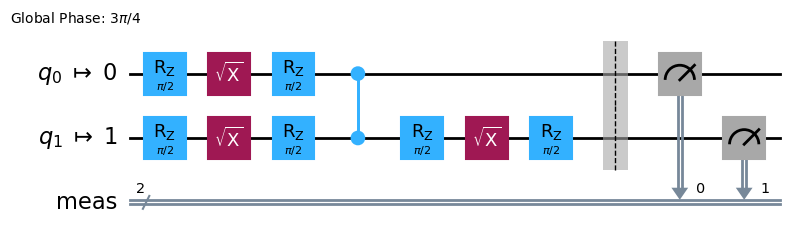

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

现在，你可以使用两种不同的collect sample的方法

Qiskit 有两个核心工具（Primitives），就像是两种不同的实验室设备：

- Sampler (采样器)：对应你最开始的代码。它像是一个照相机，记录每个比特最终是 0 还是 1 的分布情况。

- Estimator (估算器)：就是这段代码用的工具。它像是一个统计员，根据你给出的“打分规则”（Observables），计算出系统在该规则下的平均得分（期望值）。

Estimator的逻辑比较难以理解 这个里面我们使用的思路是：

通过每次实验的结果，对应$O$的结果 在500次试验后 取期望


In [5]:
 
estimator = Estimator(mode=backend)

# 设置降噪以及采样次数 
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")


NameError: name 'observables' is not defined

In [6]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]



NameError: name 'job' is not defined

In [7]:
job_result

NameError: name 'job_result' is not defined

## 对于模拟部分
我们可以采用模拟器来提前处理 


In [8]:
 
# Use the following code instead if you want to run on a simulator:
 
from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)
 
# Convert to an ISA circuit and layout-mapped observables.
 
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()
 
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
 
job_result = job.result()
 
# This is the result from our single pub, which had five observables,
# so contains information on all five.
 
pub_result = job.result()[0]

NameError: name 'observables' is not defined

现在 是看结果的时候了：

In [9]:
# Plot the result
 
from matplotlib import pyplot as plt
 
values = pub_result.data.evs
 
errors = pub_result.data.stds
 
# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

NameError: name 'pub_result' is not defined

# Scale to large numbers of qubits

在更大规模的量子计算下，下面的例子是我们如何计算多个$\langle Z_0, Z_i\rangle$

## Building the Circuit

搭建一个纵深很长的电路 一共有100个qubit

In [10]:
from qiskit import QuantumCircuit
 
 
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc) for an n-qubit GHZ state.
 
    Args:
        n (int): Number of qubits in the n-qubit GHZ state
 
    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state, assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc
 
 
# Create a new circuit with two qubits (first argument) and two classical
# bits (second argument)
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)


现在 我们对里面的每行 qubit 和 第0行比特之间的纠缠保真度进行测量 
基本的逻辑是 假如一共5个qubit

我们想知道第0个和第三个的纠缠情况，我们的Operator就是 ZIZII 只有第0位 和 第2位 有测量

In [11]:
from qiskit.quantum_info import SparsePauliOp
 
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + "I" * i + "Z" + "I" * (n - 2 - i) for i in range(n - 1)
]
print(operator_strings)
print(len(operator_strings))
 
operators = [SparsePauliOp(operator) for operator in operator_strings]

['ZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

现在转化为ISA电路

In [12]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
 
isa_circuit = pm.run(qc)
isa_operators_list = [op.apply_layout(isa_circuit.layout) for op in operators]

硬件执行：这个里面的resilience_level确定了你的纠错等级

In [13]:
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"
 
# Create an Estimator object
estimator = Estimator(backend, options=options)

运行

In [14]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()
print(job_id)

d76s98k6ji0c738c3djg


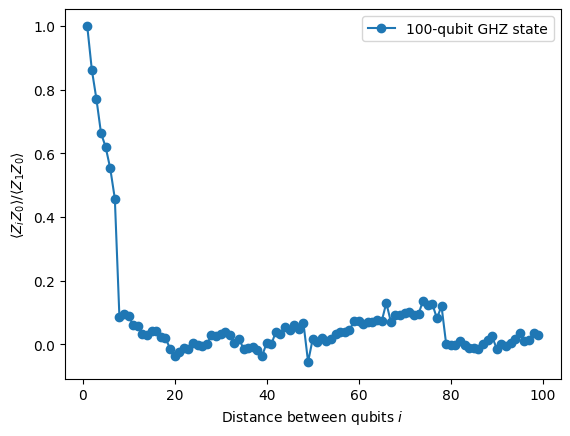

In [15]:
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService
 
# data
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.
 
# plotting graph
plt.plot(data, values, marker="o", label="100-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()